<a href="https://colab.research.google.com/github/esaghapour/HGCC_GeneTerrain/blob/main/HGCC_GeneTerrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install umap-learn

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 7.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=856603bd15a4b81beb513daf35e6dfeb65604ce9e5a35a3301677c8b5aeb78f8
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


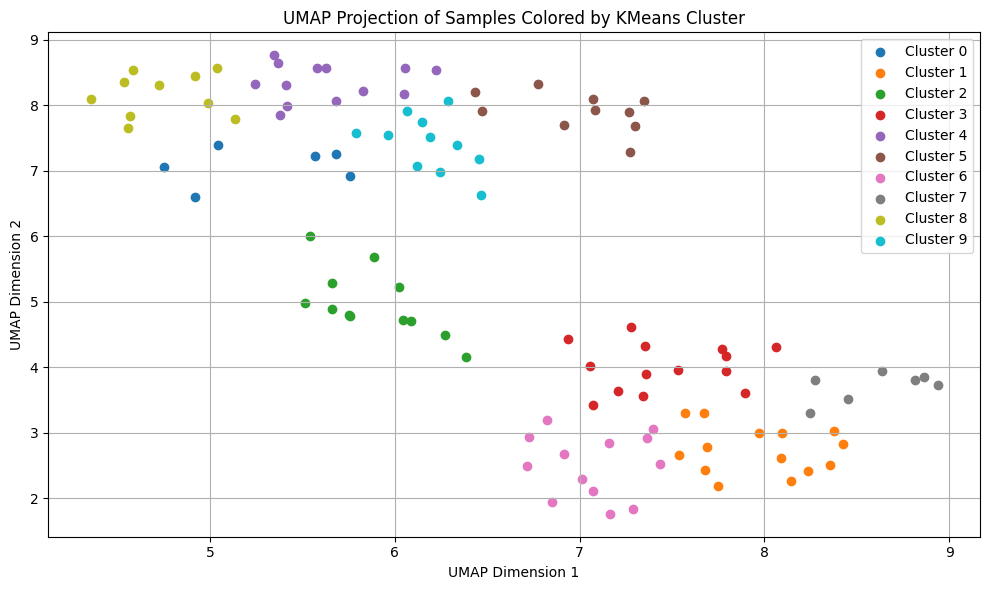

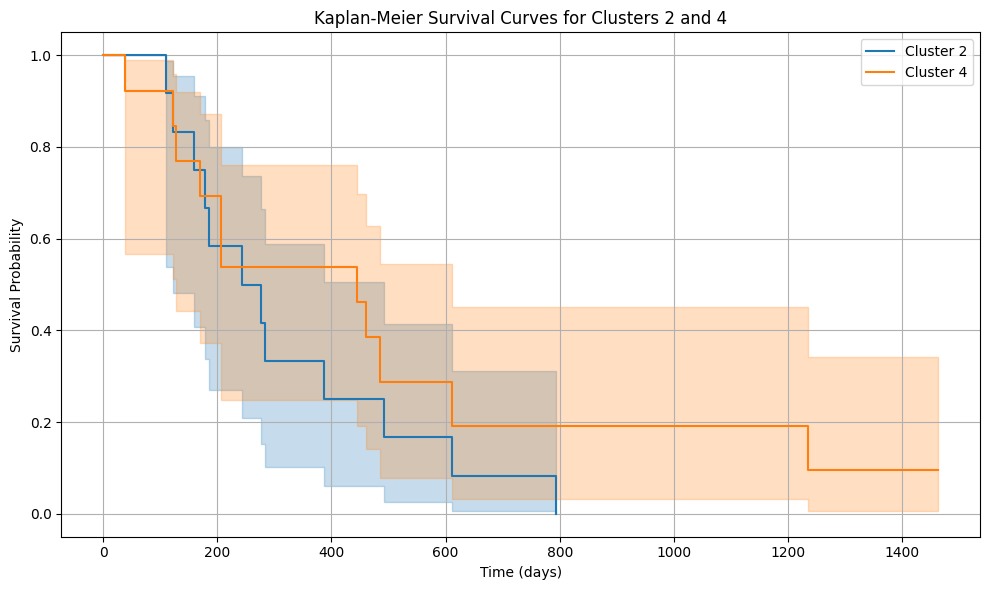

In [163]:
# Install required libraries (only needed in Colab)

# --- Step 1: Import libraries ---
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# --- Step 2: Load data ---
# Replace these with your upload or path
expression_df = pd.read_csv("HGCC_drug_response_AUC.txt", sep="\t", index_col=0)
clinical_df = pd.read_csv("HGCC_clinical.txt", sep="\t", index_col=0)

# --- Step 3: Preprocess expression data ---
expression_df = expression_df.T
expression_df.index = expression_df.index.str.extract(r'(U\d{4})')[0] + "MG"

# Impute missing values and standardize
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(expression_df)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# --- Step 4: Apply UMAP ---
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(data_scaled)

# --- Step 5: KMeans clustering ---
kmeans = KMeans(n_clusters=10, random_state=42)  # You can adjust the number of clusters
clusters = kmeans.fit_predict(umap_result)

# --- Step 6: Create UMAP DataFrame and merge with clinical ---
umap_df = pd.DataFrame(umap_result, columns=['Dim1', 'Dim2'])
umap_df['Sample'] = expression_df.index
umap_df['Cluster'] = clusters
umap_df.set_index('Sample', inplace=True)

# Merge with clinical data
merged_df = clinical_df.join(umap_df[['Cluster']], how='inner')
merged_df['Event'] = merged_df['Vitalstatus'].apply(lambda x: 1 if x == "DEAD" else 0)
merged_df['Time'] = merged_df['Survival']

# --- Step 7: Plot UMAP clustering ---
plt.figure(figsize=(10, 6))
for cluster_id in sorted(umap_df['Cluster'].unique()):
    subset = umap_df[umap_df['Cluster'] == cluster_id]
    plt.scatter(subset['Dim1'], subset['Dim2'], label=f"Cluster {cluster_id}")
plt.title("UMAP Projection of Samples Colored by KMeans Cluster")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Step 8: Kaplan-Meier plot for Clusters 2 and 4 ---
subset_km = merged_df[merged_df['Cluster'].isin([2, 4])]
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

for cluster_id in [2, 4]:
    cluster_data = subset_km[subset_km['Cluster'] == cluster_id]
    kmf.fit(cluster_data['Time'], event_observed=cluster_data['Event'], label=f"Cluster {cluster_id}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan-Meier Survival Curves for Clusters 2 and 4")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.tight_layout()
plt.show()


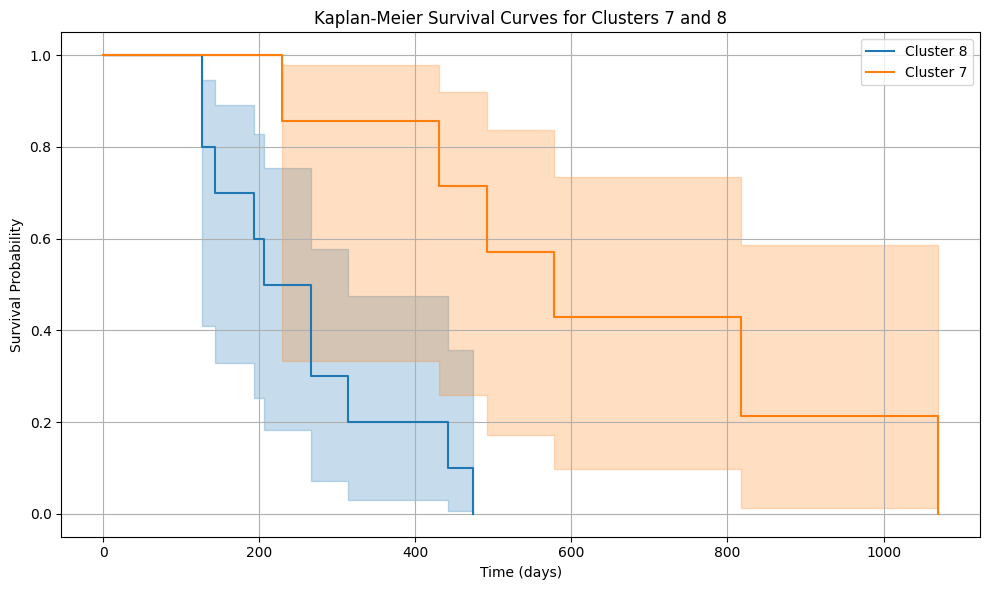

In [165]:
# --- Step 8: Kaplan-Meier plot for Clusters 7 and 8 ---
subset_km = merged_df[merged_df['Cluster'].isin([8, 7])]
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

for cluster_id in [8, 7]:
    cluster_data = subset_km[subset_km['Cluster'] == cluster_id]
    kmf.fit(cluster_data['Time'], event_observed=cluster_data['Event'], label=f"Cluster {cluster_id}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan-Meier Survival Curves for Clusters 7 and 8")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from lifelines.statistics import logrank_test

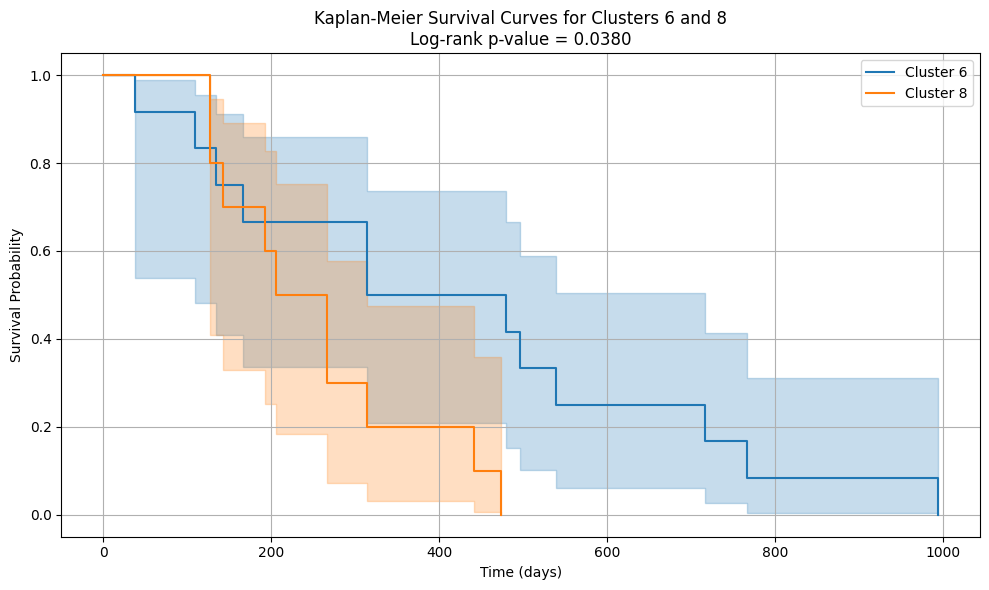

In [ ]:
# --- Step 8: Kaplan-Meier plot for Clusters 2 and 4 ---
subset_km = merged_df[merged_df['Cluster'].isin([6, 8])]
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

for cluster_id in [6,8]:
    cluster_data = subset_km[subset_km['Cluster'] == cluster_id]
    kmf.fit(cluster_data['Time'], event_observed=cluster_data['Event'], label=f"Cluster {cluster_id}")
    kmf.plot_survival_function(ci_show=True)

# --- Step 9: Log-rank test ---
group_2 = subset_km[subset_km['Cluster'] == 6]
group_4 = subset_km[subset_km['Cluster'] == 8]

results = logrank_test(
    durations_A=group_2['Time'], event_observed_A=group_2['Event'],
    durations_B=group_4['Time'], event_observed_B=group_4['Event']
)

plt.title(f"Kaplan-Meier Survival Curves for Clusters 6 and 8\nLog-rank p-value = {results.p_value:.4f}")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
from sklearn.preprocessing import StandardScaler
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



,U3102,U3123,U3129,U3137,U3140,U3146,U3164,U3167,U3169,U3172,...,U3173.1,U3175,U3180.1,U3181,U3189,U3191,U3196,U3198,U3201,U3202.1
DDX11L1,7.744229,8.268755,7.478485,8.204590,7.598614,7.692580,7.843029,7.348945,8.114587,7.953288,...,7.973217,8.317172,7.950657,7.478439,7.789083,7.299939,7.786913,8.083561,7.578251,7.612755
MIR1302,4.608089,4.403016,4.577821,4.539446,4.619722,4.673019,4.662455,4.510012,4.579550,4.468865,...,4.405787,4.540626,4.464076,4.558696,4.577493,4.631488,4.628691,4.928305,4.515373,4.632789
OR4F5,6.768606,7.327659,7.547845,6.792707,7.025850,7.052128,7.092351,6.938924,6.886199,7.096066,...,7.023418,7.601688,7.176846,6.396727,7.087330,7.217516,7.505663,7.313004,7.089356,6.835083
NaN,8.096679,8.142107,8.218315,8.099963,8.140383,8.148215,8.151461,8.051207,8.151082,8.095170,...,8.090400,8.212475,8.182829,8.137842,8.192093,8.162554,8.212475,8.189173,8.154424,8.143231
LOC100132287,20.828931,20.590219,20.225760,20.756499,21.014677,20.372146,20.743952,20.441062,20.592731,21.026507,...,20.733049,20.688196,20.729295,20.345343,21.169475,20.878196,20.528682,20.721215,20.681685,20.978423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LOC389831,21.198994,22.053991,22.420269,21.426907,22.034145,21.420647,22.152368,21.509748,21.811622,22.067436,...,21.816189,20.835772,21.413675,20.790536,21.203769,20.527655,21.598997,21.963220,22.353722,22.410117
FLJ43315,10.693549,10.779249,10.606343,10.649604,10.496172,11.078727,10.872887,10.360009,10.682441,10.357174,...,10.331944,11.134742,10.704815,10.504160,10.720382,10.770096,11.244445,10.763086,10.662386,10.836290
LINC00281,5.536456,5.640033,5.845953,5.538381,5.577498,5.868828,5.696448,6.014539,5.491725,5.463588,...,5.728854,5.826432,5.440408,5.603910,5.725242,5.778197,5.671962,5.514301,5.545460,5.642571
LOC389834,16.641732,16.296668,15.340729,16.267449,16.160946,16.402566,15.737383,15.414501,16.525466,13.725505,...,15.738758,17.587644,15.858334,15.942453,16.580345,16.064590,17.451215,16.610983,15.364466,16.919387


In [166]:
def gaussian_2D(value, x, y, x0, y0, s=1.0):
    return value * np.exp(-((x - x0)**2  + (y - y0)**2) / (s**2))

def add_gaussian_to_total(params):
    value, x0, y0, sx = params
    return gaussian_2D(value, x, y, x0, y0, sx)

In [167]:

data_matrix = pd.read_csv('HGCC_RNA_expression.txt',sep= "	")
data_matrix.index.name= "Gene"
data_matrix.head()


,U3102,U3123,U3129,U3137,U3140,U3146,U3164,U3167,U3169,U3172,...,U3173.1,U3175,U3180.1,U3181,U3189,U3191,U3196,U3198,U3201,U3202.1
Gene,,,,,,,,,,,,,,,,,,,,,
DDX11L1,7.744229,8.268755,7.478485,8.204590,7.598614,7.692580,7.843029,7.348945,8.114587,7.953288,...,7.973217,8.317172,7.950657,7.478439,7.789083,7.299939,7.786913,8.083561,7.578251,7.612755
MIR1302,4.608089,4.403016,4.577821,4.539446,4.619722,4.673019,4.662455,4.510012,4.579550,4.468865,...,4.405787,4.540626,4.464076,4.558696,4.577493,4.631488,4.628691,4.928305,4.515373,4.632789
OR4F5,6.768606,7.327659,7.547845,6.792707,7.025850,7.052128,7.092351,6.938924,6.886199,7.096066,...,7.023418,7.601688,7.176846,6.396727,7.087330,7.217516,7.505663,7.313004,7.089356,6.835083
NaN,8.096679,8.142107,8.218315,8.099963,8.140383,8.148215,8.151461,8.051207,8.151082,8.095170,...,8.090400,8.212475,8.182829,8.137842,8.192093,8.162554,8.212475,8.189173,8.154424,8.143231
LOC100132287,20.828931,20.590219,20.225760,20.756499,21.014677,20.372146,20.743952,20.441062,20.592731,21.026507,...,20.733049,20.688196,20.729295,20.345343,21.169475,20.878196,20.528682,20.721215,20.681685,20.978423


In [168]:



data_matrix=data_matrix.T


data_matrix = data_matrix.loc[:, data_matrix.columns.notna()]


variances = data_matrix.var()

high_variance_genes = variances.sort_values(ascending=False)[0:1000].index


data_matrix=data_matrix[high_variance_genes]


data_matrix



Gene,XIST,NEFL,ME1,PI15,EDIL3,POSTN,DKK1,MFAP5,NNAT,MSTN,...,CTHRC1,ARHGAP24,DPF3,LOC100506684,AKNAD1,ZNF727,SOX9,ADAMTS5,NTSR1,ROR1
U3102,2.683535,28.780922,7.676456,17.830753,3.862192,1.103428,35.301659,1.799697,6.814391,10.593697,...,9.803598,23.681686,16.719281,10.936829,16.942594,6.820902,-3.264241,7.702460,0.538762,-1.268067
U3123,-0.996261,25.686231,4.796179,12.309536,1.105296,0.099869,31.170918,-4.338261,6.304553,9.488950,...,8.767966,22.997073,15.477509,9.086809,15.836909,8.255708,-3.225341,8.188841,0.860997,-1.824122
U3129,-1.062768,30.405814,3.379500,12.485977,-0.841633,0.855058,32.129183,-3.703054,2.219919,8.163752,...,9.481265,23.770839,16.584788,8.757502,17.291227,7.990982,-3.143586,8.494775,0.745646,-2.164094
U3137,-1.183174,30.964898,4.605827,18.623294,2.132844,1.811045,36.553322,1.280380,6.235815,12.178628,...,9.140895,23.105322,16.961768,10.364160,16.763344,6.979777,-3.502008,7.886220,0.687486,-1.822929
U3140,5.106045,24.421338,5.716302,16.428992,2.926727,1.819179,34.934918,-1.680302,4.524307,11.432335,...,8.648463,22.617757,17.579366,9.709147,17.059469,6.618976,-3.562132,8.494496,0.818690,-1.857709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
U3191,4.484684,24.508458,6.718524,12.919585,0.246696,1.259262,31.255413,-2.619140,1.261486,10.380974,...,9.079624,23.194378,15.780435,10.349187,16.604719,5.894044,-2.045002,8.920232,0.530118,-2.285821
U3196,-1.148085,28.004249,8.413039,10.977385,2.612369,-2.672896,32.157608,-2.807869,1.187186,7.135549,...,11.171728,23.049844,15.865334,8.889231,15.183471,8.800367,-5.637592,8.614250,2.197895,-4.024154
U3198,-1.458614,24.552457,3.223497,12.048804,-0.143978,-4.558133,33.368761,-2.295099,1.654101,8.611633,...,8.619514,22.944212,15.855391,8.653272,16.897310,6.496213,-2.290787,8.812890,0.954805,-2.749634
U3201,4.248256,25.683850,8.899786,11.378926,5.570864,-3.731728,34.292165,-0.489662,4.897043,10.712349,...,10.412631,23.799227,16.581353,11.721112,17.303385,7.321904,-4.085925,9.868488,1.609109,-1.275559


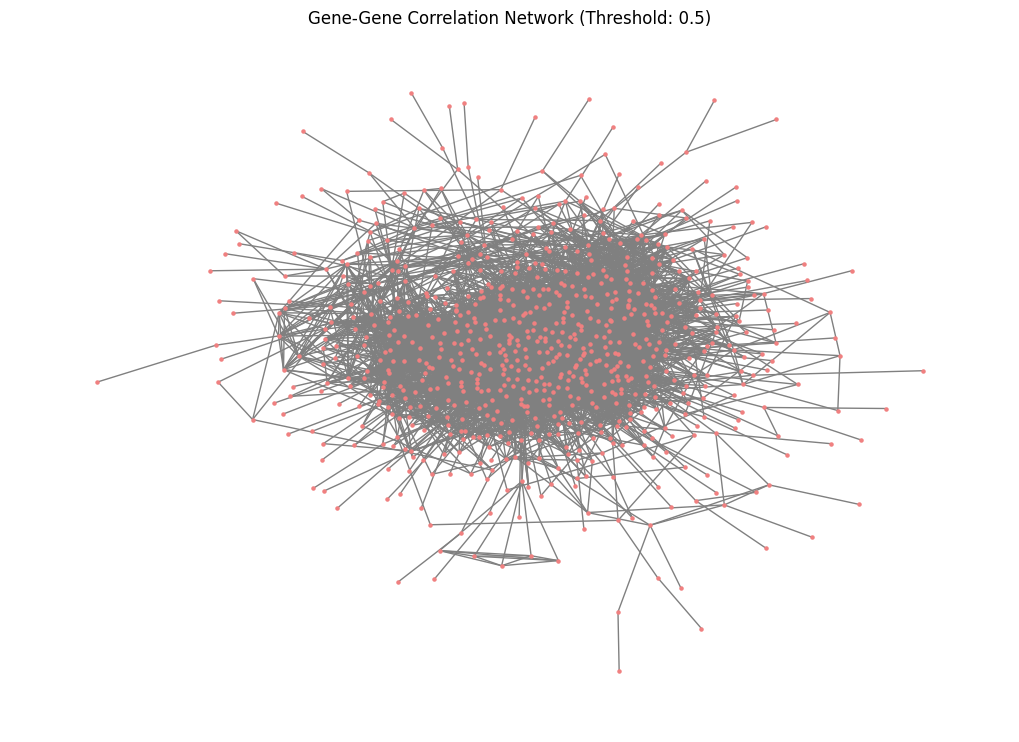

In [169]:
np.random.seed(42)


data = data_matrix
correlation_matrix = data.corr()

G_samples = nx.Graph()

# Create nodes and edges for the graph
genes = data.columns
G_samples.add_nodes_from(genes)

threshold = 0.5
for gene1 in genes:
    for gene2 in genes.difference([gene1]):
        corr_value = correlation_matrix.loc[gene1, gene2]
        if abs(corr_value) > threshold:
            G_samples.add_edge(gene1, gene2, weight=abs(corr_value))

# Remove isolated nodes and visualize
G_samples.remove_nodes_from(list(nx.isolates(G_samples)))
pos_samples = nx.kamada_kawai_layout(G_samples)

plt.figure(figsize=(10, 7))
nx.draw(G_samples, pos_samples, with_labels=False, node_size=5, node_color='lightcoral', font_size=1, width=1, edge_color='gray')
plt.title(f"Gene-Gene Correlation Network (Threshold: {threshold})")
plt.show()

# Normalize layout positions
layout = pd.DataFrame(pos_samples.values(), index=pos_samples.keys(), columns=['X', 'Y'])
layout -= layout.min()
layout /= layout.max()

In [170]:

layout


,X,Y
XIST,0.574732,0.614984
NEFL,0.737958,0.340026
PI15,0.622801,0.678465
EDIL3,0.573010,0.577623
POSTN,0.329264,0.861592
...,...,...
AKNAD1,0.735534,0.493686
ZNF727,0.642278,0.503705
SOX9,0.398362,0.532066
ADAMTS5,0.323138,0.507427


In [176]:
data_normalized=data_matrix[layout.index]
data_normalized.head()

Gene,XIST,NEFL,PI15,EDIL3,POSTN,DKK1,MFAP5,MSTN,AQP4,PMP2,...,SALL1,PKP2,ARHGAP24,DPF3,LOC100506684,AKNAD1,ZNF727,SOX9,ADAMTS5,NTSR1
U3102,2.683535,28.780922,17.830753,3.862192,1.103428,35.301659,1.799697,10.593697,4.778497,-12.112247,...,2.234094,-7.145186,23.681686,16.719281,10.936829,16.942594,6.820902,-3.264241,7.702460,0.538762
U3123,-0.996261,25.686231,12.309536,1.105296,0.099869,31.170918,-4.338261,9.488950,7.401657,-11.874526,...,1.513807,-8.212398,22.997073,15.477509,9.086809,15.836909,8.255708,-3.225341,8.188841,0.860997
U3129,-1.062768,30.405814,12.485977,-0.841633,0.855058,32.129183,-3.703054,8.163752,8.408748,-11.463643,...,2.039398,-8.407116,23.770839,16.584788,8.757502,17.291227,7.990982,-3.143586,8.494775,0.745646
U3137,-1.183174,30.964898,18.623294,2.132844,1.811045,36.553322,1.280380,12.178628,6.296846,-13.558909,...,2.554622,-7.019974,23.105322,16.961768,10.364160,16.763344,6.979777,-3.502008,7.886220,0.687486
U3140,5.106045,24.421338,16.428992,2.926727,1.819179,34.934918,-1.680302,11.432335,6.174482,-11.568226,...,2.309626,-7.458184,22.617757,17.579366,9.709147,17.059469,6.618976,-3.562132,8.494496,0.818690


In [177]:

from scipy.stats import zscore
import pandas as pd

# Assume df is your DataFrame
data_normalized = data_normalized.apply(zscore, axis=0)



data_normalized=data_normalized.T

In [183]:
data_normalized.columns=data_normalized.columns +str('MG')

In [184]:
common_samples = data_normalized.columns.intersection(merged_df.index)

In [185]:
data_normalized=data_normalized[common_samples]
data_normalized

,U3102MG,U3123MG,U3129MG,U3137MG,U3140MG,U3146MG,U3167MG,U3172MG,U3173MG,U3179MG,...,U3084MG,U3085MG,U3086MG,U3088MG,U3101MG,U3110MG,U3117MG,U3118MG,U3121MG,U3151MG
Gene,,,,,,,,,,,,,,,,,,,,,
XIST,0.555848,-0.684681,-0.707102,-0.747693,1.372521,-0.777644,-0.992061,-0.765282,1.276195,-0.893207,...,-0.829332,-0.713943,-0.764631,1.175268,-0.803715,1.247559,-0.837576,-0.851404,-0.767371,-0.704839
NEFL,0.714177,-0.452295,1.326642,1.537376,-0.929067,-0.748623,-0.015703,-0.908406,1.431127,2.090430,...,-0.407461,-0.966593,-0.713817,-0.769776,2.113034,1.521129,0.511362,1.140719,-1.008623,-0.902592
PI15,1.555621,-0.687429,-0.615748,1.877599,0.986142,-1.195885,1.512791,-0.538942,0.580400,-0.690434,...,0.280578,-0.259475,-1.021758,1.975633,1.527133,1.172702,1.005490,0.714017,0.425399,0.658183
EDIL3,0.863133,-0.288968,-1.102586,0.140442,0.472204,-1.230412,1.267131,0.853565,1.072188,-1.324497,...,0.050334,0.511507,-1.404922,0.841135,1.269974,0.085834,0.998772,0.905062,-0.773437,0.915735
POSTN,0.157145,-0.312531,0.040905,0.488317,0.492124,1.108075,0.693042,0.779097,0.568235,-2.040029,...,0.431224,-1.129862,0.888355,0.358204,-1.746759,0.326303,0.417375,0.471476,-0.109012,0.357104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AKNAD1,0.093466,-1.260417,0.520359,-0.126020,0.236577,0.153075,-0.347349,1.658338,0.575215,-0.516876,...,-0.502896,-2.279284,-0.289358,0.066936,-0.657084,-0.715651,-1.242502,-1.478591,-0.806696,1.538261
ZNF727,-0.299387,1.457863,1.133644,-0.104808,-0.546692,-1.098692,-1.081122,-0.199287,-0.479483,1.060689,...,0.253283,-1.420382,0.219194,2.744065,0.219039,-0.177761,-1.028092,-0.948365,-0.561398,0.509616
SOX9,-0.169065,-0.121418,-0.021279,-0.460298,-0.533942,0.878623,0.467997,-0.251982,-0.395100,-0.881955,...,0.560666,0.134535,0.738845,0.105353,-0.044628,0.653735,0.974997,1.144794,-0.094966,-1.149874


In [186]:

outGT = []
outGT_name = []
res = 200
sigma = 0.05

# Create grid
x = np.linspace(0, 1, res)
y = np.linspace(0, 1, res)
x, y = np.meshgrid(x, y)

#df.index=cluster.index

for name in data_normalized:

        data_cluster = data_normalized[name]
        z_total = np.zeros_like(x)
        params = zip(data_cluster, layout['X'], layout['Y'], [sigma]*layout.shape[0])

        with ThreadPoolExecutor() as executor:
            results = executor.map(add_gaussian_to_total, params)
            for z in results:
                z_total += z

        mat = z_total.reshape(1, -1)
        outGT.append(mat)
        outGT_name.append(name)

        #plt.figure()
        #plt.imshow(mat.reshape(res, res), origin='lower', cmap='jet', vmin=-10, vmax=10)
        #plt.colorbar()
        #plt.title(name)
        #plt.savefig(f'plot1/{name}.png', bbox_inches='tight')
        #plt.close()


outGT = np.reshape(outGT, (len(outGT), -1))



In [132]:
ss=merged_df.T
ss = ss.groupby(ss.columns, axis=1).first()
merged_df1=ss.loc[:,common_samples].T

<ipython-input-132-9e940333a01c>:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  ss = ss.groupby(ss.columns, axis=1).first()


In [187]:
merged_df1

,index,Subtype,Sex,Age,Survival,Vitalstatus,Cluster,Event,Time
0,U3102MG,MS,F,64,543,DEAD,1,1,543
1,U3123MG,CL,M,64,1724,ALIVE,1,0,1724
2,U3129MG,PN,F,57,433,DEAD,1,1,433
3,U3137MG,NL,M,74,1088,DEAD,1,1,1088
4,U3140MG,MS,F,67,126,DEAD,1,1,126
...,...,...,...,...,...,...,...,...,...
78,U3110MG,CL,F,58,243,DEAD,2,1,243
79,U3117MG,PN,M,57,793,DEAD,3,1,793
80,U3118MG,PN,M,57,793,DEAD,2,1,793
81,U3121MG,CL,M,64,479,DEAD,6,1,479


In [190]:
np.unique(merged_df1['Cluster'])

array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=object)

In [189]:
merged_df1.reset_index(inplace=True)

In [191]:
merged_df1[merged_df1['Cluster']==7].index

Index([5, 14, 19, 21, 26, 82], dtype='int64')

In [192]:
merged_df1[merged_df1['Cluster']==8]

,level_0,index,Subtype,Sex,Age,Survival,Vitalstatus,Cluster,Event,Time
9,9,U3179MG,NL,M,63,474,DEAD,8,1,474
10,10,U3180MG,CL,M,80,267,DEAD,8,1,267
12,12,U3187MG,NL,M,70,193,DEAD,8,1,193
15,15,U3212MG,CL,F,72,206,DEAD,8,1,206
18,18,U3217MG,MS,M,65,143,DEAD,8,1,143
46,46,U3017MG,CL,M,68,442,DEAD,8,1,442
68,68,U3065MG,CL,M,77,127,DEAD,8,1,127


In [193]:
Cluster_7=outGT[merged_df1[merged_df1['Cluster']==7].index].sum(axis=0)

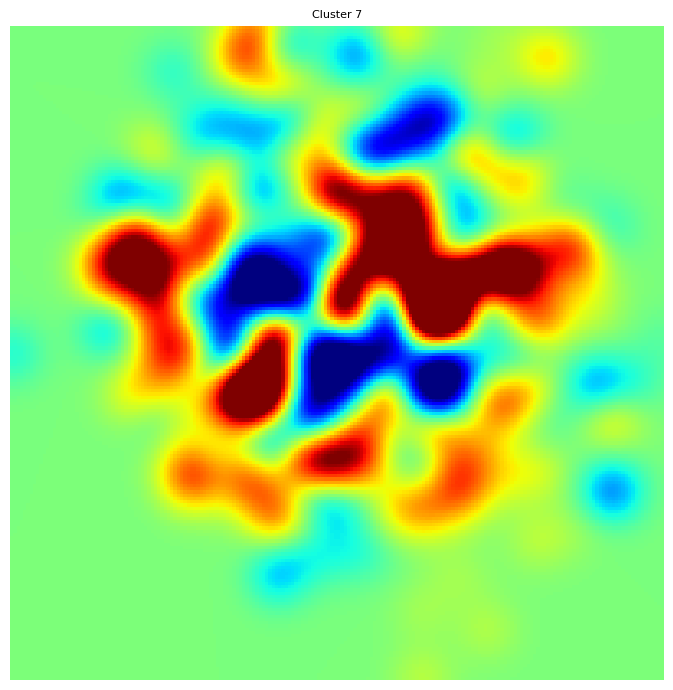

In [194]:

import matplotlib.pyplot as plt


res=200
# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(10, 7))

# Reshape the 1D array to a 2D matrix
image_matrices = Cluster_7.reshape(res, res)

# Display the image
im = ax.imshow(image_matrices, origin='lower', cmap='jet', vmin=-10, vmax=10)

# Set title and remove axes
title = "Cluster 7"
ax.set_title(title, fontsize=8)
ax.axis('off')

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()


In [195]:
Cluster_8=outGT[merged_df1[merged_df1['Cluster']==8].index].sum(axis=0)

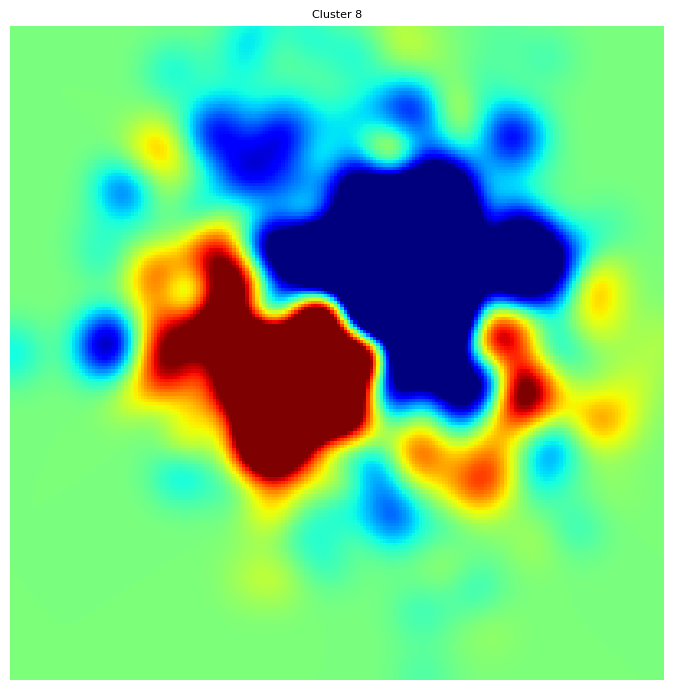

In [196]:

res=200
# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(10, 7))

# Reshape the 1D array to a 2D matrix
image_matrices = Cluster_8.reshape(res, res)

# Display the image
im = ax.imshow(image_matrices, origin='lower', cmap='jet', vmin=-10, vmax=10)

# Set title and remove axes
title = "Cluster 8"
ax.set_title(title, fontsize=8)
ax.axis('off')

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()

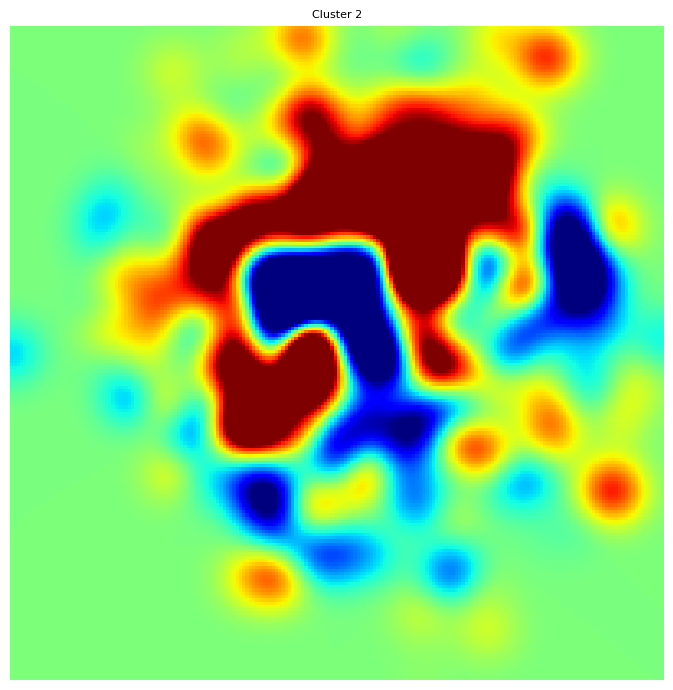

In [197]:
Cluster_2=outGT[merged_df1[merged_df1['Cluster']==2].index].sum(axis=0)

res=200
# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(10, 7))

# Reshape the 1D array to a 2D matrix
image_matrices = Cluster_2.reshape(res, res)

# Display the image
im = ax.imshow(image_matrices, origin='lower', cmap='jet', vmin=-10, vmax=10)

# Set title and remove axes
title = "Cluster 2"
ax.set_title(title, fontsize=8)
ax.axis('off')

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()

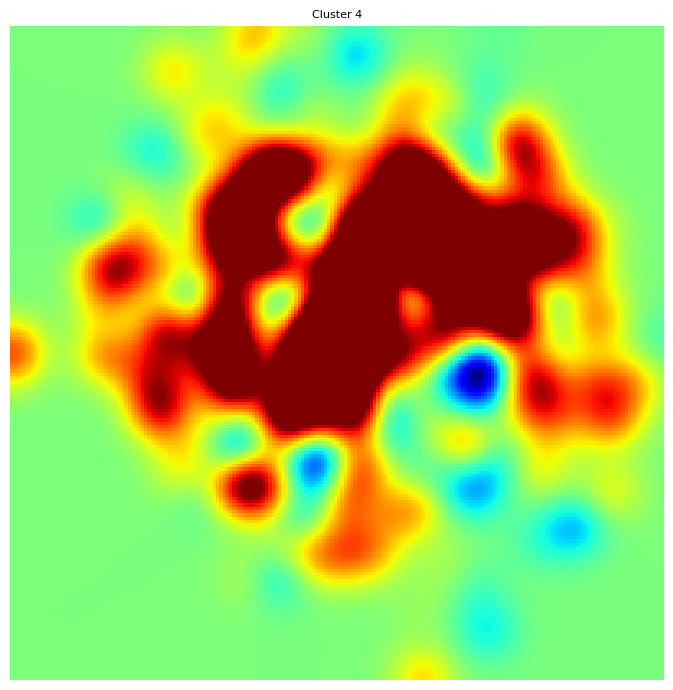

In [198]:
Cluster_4=outGT[merged_df1[merged_df1['Cluster']==4].index].sum(axis=0)

res=200
# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(10, 7))

# Reshape the 1D array to a 2D matrix
image_matrices = Cluster_4.reshape(res, res)

# Display the image
im = ax.imshow(image_matrices, origin='lower', cmap='jet', vmin=-10, vmax=10)

# Set title and remove axes
title = "Cluster 4"
ax.set_title(title, fontsize=8)
ax.axis('off')

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()

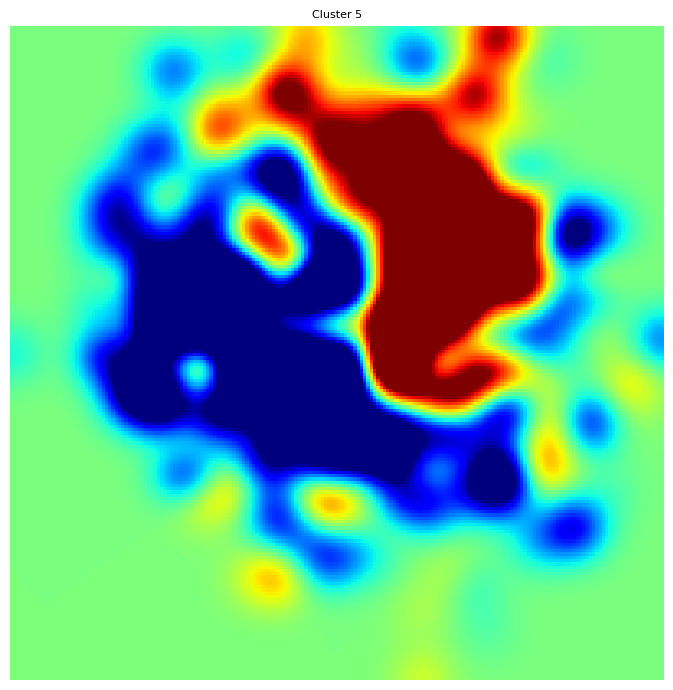

In [199]:
Cluster_5=outGT[merged_df1[merged_df1['Cluster']==5].index].sum(axis=0)

res=200
# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(10, 7))

# Reshape the 1D array to a 2D matrix
image_matrices = Cluster_5.reshape(res, res)

# Display the image
im = ax.imshow(image_matrices, origin='lower', cmap='jet', vmin=-10, vmax=10)

# Set title and remove axes
title = "Cluster 5"
ax.set_title(title, fontsize=8)
ax.axis('off')

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()